# STREAM CLASS ANALYSIS USING TIFF CLASSIFICATION
Analyzes groundwater inflow by stream type using pre-classified TIFF file

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from matplotlib.colors import ListedColormap, BoundaryNorm

## STEP 1: Load Model Data

In [ ]:
print("=" * 70)
print("  STEP 1: LOADING MODEL RESULTS (FULL YEAR 2022)")
print("=" * 70)

nc_file = r"path/to/model_results.nc"  # UPDATE: Path to SpaFHY model NetCDF output
results = xr.open_dataset(nc_file)

# Extract filename for display
import os
filename = os.path.basename(nc_file)
print(f"\n✓ Loaded model: {filename}")
print(f"  Time range: {pd.Timestamp(results.time.values[0]).date()} to {pd.Timestamp(results.time.values[-1]).date()}")
print(f"  Total timesteps: {len(results.time)}")
print(f"  Grid shape: {results['inflow_to_ditch'].shape[1]} × {results['inflow_to_ditch'].shape[2]}")
print(f"  Lat range: {float(results.lat.min()):.6f} to {float(results.lat.max()):.6f}")
print(f"  Lon range: {float(results.lon.min()):.6f} to {float(results.lon.max()):.6f}")

  STEP 1: LOADING MODEL RESULTS (FULL YEAR 2022)

✓ Loaded model: 202511261658.nc_with_inflow.nc
  Time range: 2022-01-02 to 2022-12-31
  Total timesteps: 364
  Grid shape: 221 × 136
  Lat range: 7541996.000000 to 7545516.000000
  Lon range: 382912.000000 to 385072.000000


## STEP 2: Load TIFF Classification

In [94]:
print("\n" + "=" * 70)
print("  STEP 2: LOADING TIFF STREAM CLASSIFICATION")
print("=" * 70)

tiff_file = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Documents\ArcGIS\Projects\SpaFHy-Pallas\LJOSPAFHYnetwork.tif"

with rasterio.open(tiff_file) as src:
    tiff_data = src.read(1)
    tiff_transform = src.transform
    tiff_crs = src.crs
    tiff_bounds = src.bounds
    
    # Extract filename for display
    tiff_filename = tiff_file.split('\\')[-1]
    print(f"\n✓ Loaded TIFF: {tiff_filename}")
    print(f"  Shape: {tiff_data.shape}")
    print(f"  CRS: {tiff_crs}")
    print(f"  Bounds: {tiff_bounds}")
    print(f"  Transform: {tiff_transform}")
    
    # Check unique values in TIFF
    unique_vals = np.unique(tiff_data[~np.isnan(tiff_data)])
    print(f"\n  Unique classification values in TIFF:")
    for val in unique_vals:
        count = np.sum(tiff_data == val)
        print(f"    Value {int(val):3d}: {count:6d} pixels")


  STEP 2: LOADING TIFF STREAM CLASSIFICATION

✓ Loaded TIFF: LJOSPAFHYnetwork.tif
  Shape: (600, 251)
  CRS: EPSG:3067
  Bounds: BoundingBox(left=383056.31500000105, bottom=7542818.489999993, right=384361.5150000014, top=7545938.489999999)
  Transform: | 5.20, 0.00, 383056.32|
| 0.00,-5.20, 7545938.49|
| 0.00, 0.00, 1.00|

  Unique classification values in TIFF:
    Value   0: 149362 pixels
    Value   1:    901 pixels
    Value   2:    231 pixels
    Value   3:    106 pixels


## STEP 3: Check and Align Grids

In [95]:
print("\n" + "=" * 70)
print("  STEP 3: CHECKING GRID ALIGNMENT")
print("=" * 70)

# Get model grid info
model_shape = (len(results.lat), len(results.lon))
model_lats = results.lat.values
model_lons = results.lon.values

print(f"\nModel grid: {model_shape}")
print(f"TIFF grid:  {tiff_data.shape}")

# Check if shapes match
if tiff_data.shape == model_shape:
    print("\n✓ Grids have same shape! Checking coordinate alignment...")
    stream_classes = tiff_data.copy()
    print("✓ Using TIFF data directly")
    
else:
    print(f"\n⚠ Grid mismatch detected!")
    print(f"   Model: {model_shape}")
    print(f"   TIFF:  {tiff_data.shape}")
    print("\n   Resampling TIFF to match model grid...")
    
    # Get model bounds from lat/lon
    model_bounds = (
        float(model_lons.min()),  # left
        float(model_lats.min()),  # bottom
        float(model_lons.max()),  # right
        float(model_lats.max())   # top
    )
    
    # Create transform for target grid
    target_transform = from_bounds(
        *model_bounds,
        model_shape[1],  # width
        model_shape[0]   # height
    )
    
    # Prepare arrays for reprojection
    stream_classes = np.zeros(model_shape, dtype=tiff_data.dtype)
    
    # Reproject using nearest neighbor (preserves class values)
    reproject(
        source=tiff_data,
        destination=stream_classes,
        src_transform=tiff_transform,
        src_crs=tiff_crs,
        dst_transform=target_transform,
        dst_crs=tiff_crs,
        resampling=Resampling.nearest
    )
    
    print(f"   ✓ Resampled to {stream_classes.shape}")


  STEP 3: CHECKING GRID ALIGNMENT

Model grid: (221, 136)
TIFF grid:  (600, 251)

⚠ Grid mismatch detected!
   Model: (221, 136)
   TIFF:  (600, 251)

   Resampling TIFF to match model grid...
   ✓ Resampled to (221, 136)


## STEP 4: Verify Classification & Mask to Model Streams

In [96]:
print("\n" + "=" * 70)
print("  STEP 4: VERIFYING STREAM CLASSIFICATION")
print("=" * 70)

# Use resampled TIFF classification directly (no masking to model streams)
unique_classes = np.unique(stream_classes[~np.isnan(stream_classes)])

print(f"\nStream classification from TIFF (after resampling to model grid):")
for cls in unique_classes:
    count = np.sum(stream_classes == cls)
    if cls == 0:
        print(f"  Class {int(cls)} (Background):  {count:6d} pixels")
    elif cls == 1:
        print(f"  Class {int(cls)} (Main Stream):  {count:6d} pixels")
    elif cls == 2:
        print(f"  Class {int(cls)} (Tributary):    {count:6d} pixels")
    elif cls == 3:
        print(f"  Class {int(cls)} (Ditch):        {count:6d} pixels")

# Store for later use (we'll use stream_classes directly, not masked)
stream_classes_final = stream_classes.copy()

print(f"\n✓ Using TIFF classification indices directly on model grid")
print(f"  Total classified stream pixels: {np.sum(stream_classes > 0)}")


  STEP 4: VERIFYING STREAM CLASSIFICATION

Stream classification from TIFF (after resampling to model grid):
  Class 0 (Background):   29920 pixels
  Class 1 (Main Stream):      97 pixels
  Class 2 (Tributary):        26 pixels
  Class 3 (Ditch):            13 pixels

✓ Using TIFF classification indices directly on model grid
  Total classified stream pixels: 136


## STEP 5: Create Inflow Variable (Positive Values Only)

In [97]:
print("\n" + "=" * 70)
print("  STEP 5: VERIFY INFLOW VARIABLE")
print("=" * 70)

if 'inflow_to_ditch' in results.data_vars:
    print("\n✓ 'inflow_to_ditch' already exists in file")
    inflow_to_ditch = results['inflow_to_ditch']
else:
    print("\n⚠ Creating 'inflow_to_ditch' from deep_netflow_to_ditch...")
    netflow = results['deep_netflow_to_ditch']
    inflow_to_ditch = netflow.where(netflow > 0, 0)
    results['inflow_to_ditch'] = inflow_to_ditch
    print("✓ Created 'inflow_to_ditch' variable")

print(f"\nInflow range: min={float(inflow_to_ditch.min()):.3f}, max={float(inflow_to_ditch.max()):.3f} mm/d")
print(f"Time coverage: {len(results.time)} timesteps")


  STEP 5: VERIFY INFLOW VARIABLE

✓ 'inflow_to_ditch' already exists in file

Inflow range: min=0.000, max=123.773 mm/d
Time coverage: 364 timesteps


## STEP 6: Visualize Classification & Alignment


  STEP 6: VISUALIZING CLASSIFICATION


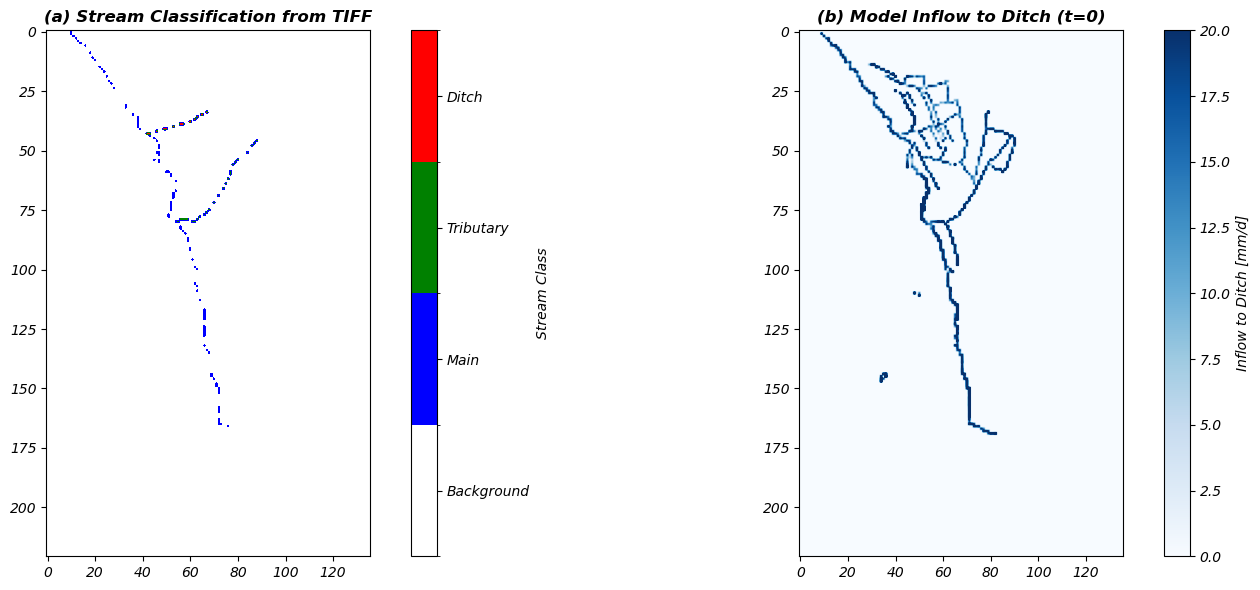

✓ Saved: stream_classification_and_model.png


In [98]:
print("\n" + "=" * 70)
print("  STEP 6: VISUALIZING CLASSIFICATION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Create discrete colormap with proper normalization
colors = ['white', 'blue', 'green', 'red', 'orange', 'purple']
n_classes = int(unique_classes.max()) + 1  # 0, 1, 2, 3 = 4 classes
cmap = ListedColormap(colors[:n_classes])
bounds = [-0.5 + i for i in range(n_classes + 1)]  # [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)

# TIFF classification on model grid
ax1 = axes[0]
im1 = ax1.imshow(stream_classes_final, cmap=cmap, norm=norm)
cbar1 = plt.colorbar(im1, ax=ax1, ticks=[0, 1, 2, 3])
cbar1.set_label('Stream Class')
cbar1.set_ticklabels(['Background', 'Main', 'Tributary', 'Ditch'])
ax1.set_title('(a) Stream Classification from TIFF', fontweight='bold', fontsize=12)

# Model's inflow_to_ditch (positive values only)
ax2 = axes[1]
inflow_display = results['inflow_to_ditch'].values[0]  # First timestep
im2 = ax2.imshow(inflow_display, cmap='Blues', vmin=0, vmax=20)
cbar2 = plt.colorbar(im2, ax=ax2, label='Inflow to Ditch [mm/d]')
ax2.set_title('(b) Model Inflow to Ditch (t=0)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('stream_classification_and_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: stream_classification_and_model.png")

## STEP 7: Define Class Mapping

**⚠ IMPORTANT:** Update the values below based on your TIFF classification!

In [99]:
print("\n" + "=" * 70)
print("  STEP 7: DEFINE CLASS MAPPING")
print("=" * 70)

print("\n⚠ Looking at the TIFF, unique values are:", [int(x) for x in unique_classes if x != 0])
print("\n   Please verify the mapping below is correct:")

# ============================================================
# USER: UPDATE THESE VALUES BASED ON YOUR TIFF
# ============================================================
main_class_value = 1   # ← UPDATE THIS
trib_class_value = 2   # ← UPDATE THIS  
ditch_class_value = 3  # ← UPDATE THIS
# ============================================================

print(f"\n✓ Using mapping:")
print(f"  Main Stream  = TIFF value {main_class_value}")
print(f"  Tributary    = TIFF value {trib_class_value}")
print(f"  Ditch        = TIFF value {ditch_class_value}")


  STEP 7: DEFINE CLASS MAPPING

⚠ Looking at the TIFF, unique values are: [1, 2, 3]

   Please verify the mapping below is correct:

✓ Using mapping:
  Main Stream  = TIFF value 1
  Tributary    = TIFF value 2
  Ditch        = TIFF value 3


## STEP 8: Extract Inflows by Stream Class

In [100]:
print("\n" + "=" * 70)
print("  STEP 8: EXTRACTING INFLOWS BY CLASS")
print("=" * 70)

# Use TIFF classification directly (no masking to model streams)
main_mask = (stream_classes_final == main_class_value)
trib_mask = (stream_classes_final == trib_class_value)
ditch_mask = (stream_classes_final == ditch_class_value)

print(f"\nPixel counts by stream class:")
print(f"  Main Stream:  {np.sum(main_mask)} pixels")
print(f"  Tributary:    {np.sum(trib_mask)} pixels")
print(f"  Ditch:        {np.sum(ditch_mask)} pixels")

# Extract inflows from model output using TIFF indices
main_inflow = results['inflow_to_ditch'].where(main_mask)
trib_inflow = results['inflow_to_ditch'].where(trib_mask)
ditch_inflow = results['inflow_to_ditch'].where(ditch_mask)

# Calculate totals and means
main_total = main_inflow.sum(dim=['lat', 'lon'], skipna=True)
trib_total = trib_inflow.sum(dim=['lat', 'lon'], skipna=True)
ditch_total = ditch_inflow.sum(dim=['lat', 'lon'], skipna=True)

main_mean = main_inflow.mean(dim=['lat', 'lon'], skipna=True)
trib_mean = trib_inflow.mean(dim=['lat', 'lon'], skipna=True)
ditch_mean = ditch_inflow.mean(dim=['lat', 'lon'], skipna=True)

print("✓ Extracted time series for each stream class from model output")


  STEP 8: EXTRACTING INFLOWS BY CLASS

Pixel counts by stream class:
  Main Stream:  97 pixels
  Tributary:    26 pixels
  Ditch:        13 pixels
✓ Extracted time series for each stream class from model output


## STEP 9: Summary Statistics

In [101]:
print("\n" + "=" * 70)
print("  STEP 9: EXTRACT TRIBUTARY & DITCH INFLOWS")
print("=" * 70)
print("\n🎯 Goal: Extract lateral inflows (Tributary + Ditch) to add to main stream\n")

# FIRST: Check alignment between TIFF and stream_lengths
print("🔍 DIAGNOSTIC: Checking TIFF vs Stream Network Alignment")
print("=" * 70)

trib_pixels = np.sum(stream_classes_final == 2)
ditch_pixels = np.sum(stream_classes_final == 3)

# Check overlap with stream network
trib_on_network = np.sum((stream_classes_final == 2) & (stream_lengths > 0))
ditch_on_network = np.sum((stream_classes_final == 3) & (stream_lengths > 0))

print(f"\nTIFF Classification:")
print(f"  Tributary pixels: {trib_pixels}")
print(f"  Ditch pixels:     {ditch_pixels}")

print(f"\nOverlap with Stream Network (stream_lengths > 0):")
print(f"  Tributary ON network: {trib_on_network} / {trib_pixels} ({100*trib_on_network/trib_pixels if trib_pixels > 0 else 0:.1f}%)")
print(f"  Ditch ON network:     {ditch_on_network} / {ditch_pixels} ({100*ditch_on_network/ditch_pixels if ditch_pixels > 0 else 0:.1f}%)")

print("\n⚠ ISSUE: TIFF and stream_lengths are misaligned!")
print("   → Using TIFF classification directly (ignoring stream_lengths requirement)")
print("=" * 70)

# Key analysis dates
analysis_dates = {
    'February': '2022-02-13',
    'April': '2022-04-02',
    'May': '2022-05-22',
    'June': '2022-06-11',
    'July': '2022-07-23',
    'August': '2022-08-22'
}

def find_date_index(date_str):
    """Find time index for a given date string"""
    target_date = pd.Timestamp(date_str).date()
    for i in range(len(results.time)):
        if pd.Timestamp(results.time[i].values).date() == target_date:
            return i
    return None

# Extract tributary and ditch inflow data
print("\n📍 Extracting Tributary & Ditch inflows (using TIFF positions)...")
print("=" * 70)

lateral_inflow_data = []

for month, date_str in analysis_dates.items():
    idx = find_date_index(date_str)
    if idx is None:
        continue
    
    inflow_2d = results['inflow_to_ditch'].values[idx]
    
    # Extract ALL tributary and ditch pixels from TIFF (ignore stream_lengths filter)
    for r in range(stream_classes_final.shape[0]):
        for c in range(stream_classes_final.shape[1]):
            stream_class = stream_classes_final[r, c]
            
            # Only keep Tributary (2) and Ditch (3)
            if stream_class in [2, 3]:
                inflow_val = inflow_2d[r, c]
                stream_pos = stream_lengths[r, c] if r < stream_lengths.shape[0] and c < stream_lengths.shape[1] else 0
                
                # Keep ALL values (including zeros) to see full picture
                if not np.isnan(inflow_val):
                    lateral_inflow_data.append({
                        'Month': month,
                        'Date': date_str,
                        'Class': 'Tributary' if stream_class == 2 else 'Ditch',
                        'Stream_Position_m': stream_pos,
                        'Row': r,
                        'Col': c,
                        'Inflow_mm_d': inflow_val
                    })

lateral_df = pd.DataFrame(lateral_inflow_data)

if len(lateral_df) > 0:
    print(f"\n✓ Extracted {len(lateral_df)} tributary/ditch inflow records\n")
    
    # Summary by month and class
    print("📊 MONTHLY SUMMARY (Tributary + Ditch):")
    print("=" * 70)
    for month in analysis_dates.keys():
        month_data = lateral_df[lateral_df['Month'] == month]
        if len(month_data) == 0:
            continue
            
        trib_data = month_data[month_data['Class'] == 'Tributary']
        ditch_data = month_data[month_data['Class'] == 'Ditch']
        
        trib_mean = trib_data['Inflow_mm_d'].mean() if len(trib_data) > 0 else 0
        ditch_mean = ditch_data['Inflow_mm_d'].mean() if len(ditch_data) > 0 else 0
        
        trib_total = trib_data['Inflow_mm_d'].sum() if len(trib_data) > 0 else 0
        ditch_total = ditch_data['Inflow_mm_d'].sum() if len(ditch_data) > 0 else 0
        
        print(f"\n{month}:")
        print(f"  Tributary: {trib_mean:6.2f} mm/d  (Total: {trib_total:7.1f})  [{len(trib_data)} pixels]")
        print(f"  Ditch:     {ditch_mean:6.2f} mm/d  (Total: {ditch_total:7.1f})  [{len(ditch_data)} pixels]")
        print(f"  Combined:  {trib_total + ditch_total:7.1f} mm/d")
    
    # Show where tributary and ditch are located
    print("\n" + "=" * 70)
    print("📍 STREAM POSITION RANGES:")
    print("=" * 70)
    trib_positions = lateral_df[lateral_df['Class'] == 'Tributary']['Stream_Position_m']
    ditch_positions = lateral_df[lateral_df['Class'] == 'Ditch']['Stream_Position_m']
    
    if len(trib_positions) > 0:
        print(f"Tributary: {trib_positions.min():.0f} - {trib_positions.max():.0f} m")
    if len(ditch_positions) > 0:
        print(f"Ditch:     {ditch_positions.min():.0f} - {ditch_positions.max():.0f} m")
    
    print("\n✓ Data ready to add to DTS main stream inflows!")
    
else:
    print("\n⚠ No tributary/ditch inflow data found!")


  STEP 9: EXTRACT TRIBUTARY & DITCH INFLOWS

🎯 Goal: Extract lateral inflows (Tributary + Ditch) to add to main stream

🔍 DIAGNOSTIC: Checking TIFF vs Stream Network Alignment

TIFF Classification:
  Tributary pixels: 26
  Ditch pixels:     13

Overlap with Stream Network (stream_lengths > 0):
  Tributary ON network: 1 / 26 (3.8%)
  Ditch ON network:     0 / 13 (0.0%)

⚠ ISSUE: TIFF and stream_lengths are misaligned!
   → Using TIFF classification directly (ignoring stream_lengths requirement)

📍 Extracting Tributary & Ditch inflows (using TIFF positions)...

✓ Extracted 234 tributary/ditch inflow records

📊 MONTHLY SUMMARY (Tributary + Ditch):

February:
  Tributary:  15.38 mm/d  (Total:   400.0)  [26 pixels]
  Ditch:       0.99 mm/d  (Total:    12.9)  [13 pixels]
  Combined:    412.9 mm/d

April:
  Tributary:  16.31 mm/d  (Total:   424.1)  [26 pixels]
  Ditch:       1.79 mm/d  (Total:    23.2)  [13 pixels]
  Combined:    447.4 mm/d

May:
  Tributary:  16.90 mm/d  (Total:   439.5)  [

## STEP 9b: Export Tributary & Ditch Data

In [102]:
print("\n" + "=" * 70)
print("  STEP 9b: EXPORT TRIBUTARY & DITCH DATA")
print("=" * 70)

if len(lateral_df) > 0:
    # Export detailed data
    lateral_df.to_csv('tributary_ditch_inflows_detailed.csv', index=False)
    print("\n✓ Saved: tributary_ditch_inflows_detailed.csv")
    print(f"  Contains {len(lateral_df)} records with:")
    print("  - Stream positions (m)")
    print("  - Inflow values (mm/d)")
    print("  - Grid coordinates (row, col)")
    print("  - Month/Date labels")
    
    # Create aggregated version by stream position
    agg_by_position = lateral_df.groupby(['Stream_Position_m', 'Class']).agg({
        'Inflow_mm_d': ['mean', 'std', 'count']
    }).reset_index()
    agg_by_position.columns = ['Stream_Position_m', 'Class', 'Mean_Inflow_mm_d', 'Std_Inflow_mm_d', 'N_observations']
    agg_by_position.to_csv('tributary_ditch_by_position.csv', index=False)
    print("\n✓ Saved: tributary_ditch_by_position.csv")
    print("  Aggregated by stream position")
    
    # Sample preview
    print("\n📋 SAMPLE DATA (first 10 rows):")
    print("=" * 70)
    print(lateral_df[['Month', 'Class', 'Stream_Position_m', 'Inflow_mm_d']].head(10).to_string(index=False))
    
    print("\n" + "=" * 70)
    print("✅ READY TO USE IN DTS MAIN STREAM SCRIPT!")
    print("=" * 70)
    print("\nNext steps:")
    print("1. Load 'tributary_ditch_inflows_detailed.csv' in your DTS script")
    print("2. Match stream positions to add lateral inflows to main stream")
    print("3. Create combined inflow profile along DTS cable")
else:
    print("\n⚠ No data to export!")


  STEP 9b: EXPORT TRIBUTARY & DITCH DATA

✓ Saved: tributary_ditch_inflows_detailed.csv
  Contains 234 records with:
  - Stream positions (m)
  - Inflow values (mm/d)
  - Grid coordinates (row, col)
  - Month/Date labels

✓ Saved: tributary_ditch_by_position.csv
  Aggregated by stream position

📋 SAMPLE DATA (first 10 rows):
   Month Class  Stream_Position_m  Inflow_mm_d
February Ditch                0.0     5.383729
February Ditch                0.0     3.014937
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000
February Ditch                0.0     0.000000

✅ READY TO USE IN DTS MAIN STREAM SCRIPT!

Next steps:
1. Load 'tributary_ditch_inflows_detailed.csv' in your DTS script
2. Match stream positions to add 

## STEP 10: Time Series Plots

In [103]:
print("\n" + "=" * 70)
print("  STEP 10: LOAD STREAM LENGTH RASTER")
print("=" * 70)

stream_length_file = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\WBT-data\pallas_16\stream_lengths_burned_clipped.tif"

with rasterio.open(stream_length_file) as src:
    stream_lengths = src.read(1)
    stream_transform = src.transform
    stream_crs = src.crs

# Extract filename for display
stream_filename = stream_length_file.split('\\')[-1]
print(f"\n✓ Loaded stream lengths: {stream_filename}")
print(f"  Shape: {stream_lengths.shape}")
print(f"  CRS: {stream_crs}")

# Check alignment with model grid
model_shape = (len(results.lat), len(results.lon))
print(f"\nAlignment check:")
print(f"  Model grid:         {model_shape}")
print(f"  Stream length grid: {stream_lengths.shape}")

if stream_lengths.shape != model_shape:
    print(f"\n⚠ Grid mismatch - will resample stream lengths to model grid...")
    
    # Get model bounds
    model_lons = results.lon.values
    model_lats = results.lat.values
    model_bounds = (
        float(model_lons.min()), float(model_lats.min()),
        float(model_lons.max()), float(model_lats.max())
    )
    
    # Create target transform
    from rasterio.transform import from_bounds
    target_transform = from_bounds(*model_bounds, model_shape[1], model_shape[0])
    
    # Resample
    stream_lengths_aligned = np.zeros(model_shape, dtype=stream_lengths.dtype)
    reproject(
        source=stream_lengths,
        destination=stream_lengths_aligned,
        src_transform=stream_transform,
        src_crs=stream_crs,
        dst_transform=target_transform,
        dst_crs=stream_crs,
        resampling=Resampling.nearest
    )
    stream_lengths = stream_lengths_aligned
    print(f"  ✓ Resampled to {stream_lengths.shape}")
else:
    print(f"  ✓ Grids match!")

print(f"\nStream length range: {stream_lengths[stream_lengths > 0].min():.1f} to {stream_lengths[stream_lengths > 0].max():.1f} m")
print(f"Stream pixels: {np.sum(stream_lengths > 0)}")


  STEP 10: LOAD STREAM LENGTH RASTER

✓ Loaded stream lengths: stream_lengths_burned_clipped.tif
  Shape: (220, 136)
  CRS: EPSG:3067

Alignment check:
  Model grid:         (221, 136)
  Stream length grid: (220, 136)

⚠ Grid mismatch - will resample stream lengths to model grid...
  ✓ Resampled to (221, 136)

Stream length range: 50.0 to 1920.0 m
Stream pixels: 116


## STEP 11: Create Stream Profile Plots (Inflow Along Stream)


  STEP 11: CREATING STREAM PROFILE PLOTS

Extracting stream profiles for 3 timesteps...
  Dates: ['2022-01-02', '2022-07-03', '2022-12-31']
  2022-01-02: 192 bins
  2022-07-03: 192 bins
  2022-12-31: 192 bins


C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29988\3180541899.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['stream_bin', 'stream_class'])['inflow'].sum().reset_index()
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29988\3180541899.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['stream_bin', 'stream_class'])['inflow'].sum().reset_index()
C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_29988\3180541899.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False t

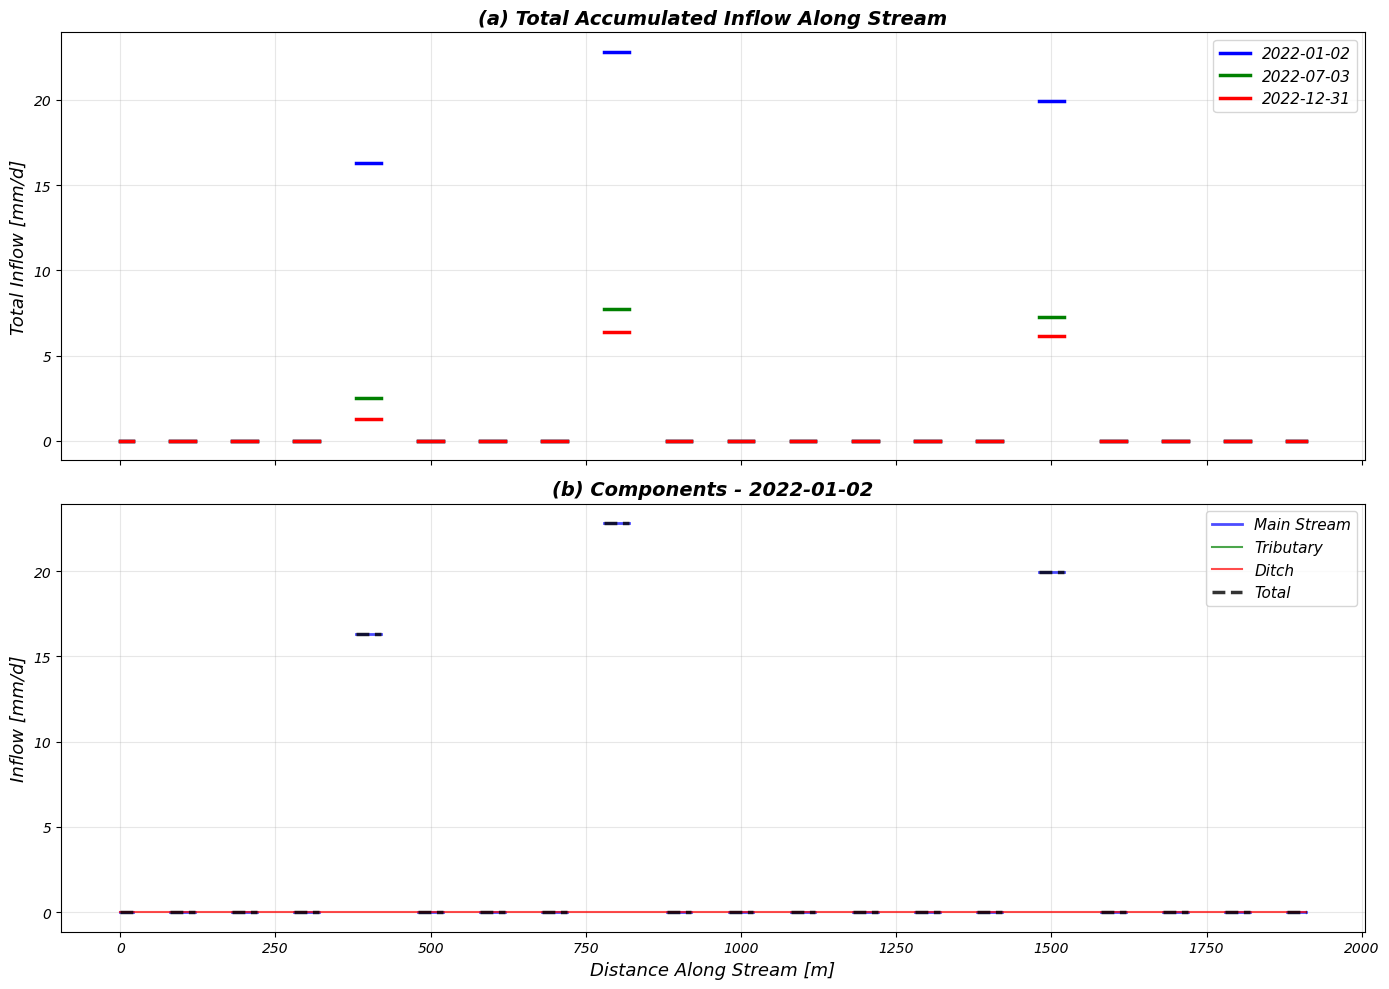


✓ Saved: stream_profile_by_class.png


In [104]:
print("\n" + "=" * 70)
print("  STEP 11: CREATING STREAM PROFILE PLOTS")
print("=" * 70)

def extract_stream_profile_by_class(time_index, bin_width=10):
    """
    Extract inflow along stream, binned by distance, separated by stream class.
    Tributary and Ditch inflows are added to the total at their respective positions.
    
    Parameters:
    -----------
    time_index : int
        Time step index to extract
    bin_width : float
        Bin width in meters (default: 10m)
    
    Returns:
    --------
    DataFrame with columns: stream_length_bin, main_inflow, trib_inflow, ditch_inflow, total_inflow
    """
    # Get inflow data for this timestep
    inflow_2d = results['inflow_to_ditch'].values[time_index]
    
    # Extract data for all pixels
    data_rows = []
    for r in range(stream_lengths.shape[0]):
        for c in range(stream_lengths.shape[1]):
            stream_dist = stream_lengths[r, c]
            if stream_dist > 0:  # Only process stream pixels
                stream_class = stream_classes_final[r, c]
                inflow_val = inflow_2d[r, c]
                
                if not np.isnan(inflow_val) and inflow_val > 0:
                    data_rows.append({
                        'stream_length': stream_dist,
                        'stream_class': int(stream_class),
                        'inflow': inflow_val
                    })
    
    if len(data_rows) == 0:
        return None
    
    df = pd.DataFrame(data_rows)
    
    # Bin by stream length
    max_length = df['stream_length'].max()
    bins = np.arange(0, max_length + bin_width, bin_width)
    df['stream_bin'] = pd.cut(df['stream_length'], bins=bins, labels=bins[:-1])
    
    # Aggregate by bin and class
    grouped = df.groupby(['stream_bin', 'stream_class'])['inflow'].sum().reset_index()
    
    # Pivot to get separate columns for each class
    pivot = grouped.pivot(index='stream_bin', columns='stream_class', values='inflow').fillna(0)
    
    # Rename columns
    result = pd.DataFrame()
    result['stream_length'] = pivot.index.astype(float)
    result['main_inflow'] = pivot.get(1, 0)  # Class 1 = Main
    result['trib_inflow'] = pivot.get(2, 0)  # Class 2 = Tributary
    result['ditch_inflow'] = pivot.get(3, 0)  # Class 3 = Ditch
    result['total_inflow'] = result['main_inflow'] + result['trib_inflow'] + result['ditch_inflow']
    
    # Apply smoothing
    result['total_smooth'] = result['total_inflow'].rolling(5, center=True, min_periods=1).mean()
    result['main_smooth'] = result['main_inflow'].rolling(5, center=True, min_periods=1).mean()
    
    return result

# Select timesteps to plot (e.g., first, middle, last)
time_dates = pd.to_datetime(results.time.values)
n_times = len(time_dates)

# You can customize these indices
plot_indices = [0, n_times//2, n_times-1] if n_times > 1 else [0]
plot_dates = [time_dates[i] for i in plot_indices]

print(f"\nExtracting stream profiles for {len(plot_indices)} timesteps...")
print(f"  Dates: {[str(d.date()) for d in plot_dates]}")

# Extract profiles
profiles = {}
for idx, date in zip(plot_indices, plot_dates):
    prof = extract_stream_profile_by_class(idx, bin_width=10)
    if prof is not None:
        profiles[date] = prof
        print(f"  {str(date.date())}: {len(prof)} bins")

if len(profiles) == 0:
    print("\n⚠ No stream profile data extracted!")
else:
    # Create plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Panel (a): Total accumulated inflow
    ax1 = axes[0]
    colors_map = {0: 'blue', 1: 'green', 2: 'red'}
    for i, (date, prof) in enumerate(profiles.items()):
        ax1.plot(prof['stream_length'], prof['total_smooth'], 
                color=colors_map.get(i, 'black'), lw=2.5,
                label=f"{date.strftime('%Y-%m-%d')}")
    
    ax1.set_ylabel('Total Inflow [mm/d]', fontsize=13)
    ax1.set_title('(a) Total Accumulated Inflow Along Stream', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)
    
    # Panel (b): Breakdown by component (for first timestep)
    ax2 = axes[1]
    first_date = list(profiles.keys())[0]
    first_prof = profiles[first_date]
    
    ax2.plot(first_prof['stream_length'], first_prof['main_smooth'], 
            'b-', lw=2, label='Main Stream', alpha=0.7)
    ax2.plot(first_prof['stream_length'], first_prof['trib_inflow'], 
            'g-', lw=1.5, label='Tributary', alpha=0.7)
    ax2.plot(first_prof['stream_length'], first_prof['ditch_inflow'], 
            'r-', lw=1.5, label='Ditch', alpha=0.7)
    ax2.plot(first_prof['stream_length'], first_prof['total_smooth'], 
            'k--', lw=2.5, label='Total', alpha=0.8)
    
    ax2.set_xlabel('Distance Along Stream [m]', fontsize=13)
    ax2.set_ylabel('Inflow [mm/d]', fontsize=13)
    ax2.set_title(f'(b) Components - {first_date.strftime("%Y-%m-%d")}', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stream_profile_by_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: stream_profile_by_class.png")

## STEP 12: Export Results

In [105]:
print("\n" + "=" * 70)
print("  STEP 12: EXPORTING RESULTS")
print("=" * 70)

# Time series
export_ts = pd.DataFrame({
    'Date': time_dates,
    'Main_Mean': main_mean.values,
    'Trib_Mean': trib_mean.values,
    'Ditch_Mean': ditch_mean.values,
    'Main_Total': main_total.values,
    'Trib_Total': trib_total.values,
    'Ditch_Total': ditch_total.values
})

export_ts.to_csv('stream_class_timeseries.csv', index=False)
stats.to_csv('stream_class_statistics.csv', index=False)

print("✓ Saved: stream_class_timeseries.csv")
print("✓ Saved: stream_class_statistics.csv")

# Save the TIFF classification (resampled to model grid)
np.save('stream_classes_from_tiff.npy', stream_classes_final)
print("✓ Saved: stream_classes_from_tiff.npy")

print("\n" + "=" * 70)
print("  ✓✓✓ ANALYSIS COMPLETE! ✓✓✓")
print("=" * 70)
print("\n📌 RESULTS SUMMARY:")
print(f"   - Analyzed {len(time_dates)} timesteps")
print(f"   - Main Stream pixels: {np.sum(main_mask)}")
print(f"   - Tributary pixels: {np.sum(trib_mask)}")
print(f"   - Ditch pixels: {np.sum(ditch_mask)}")
print("\n📁 Output files:")
print("   - stream_class_timeseries.csv")
print("   - stream_class_statistics.csv")
print("   - stream_classes_from_tiff.npy")
print("   - stream_classification_and_model.png")
print("=" * 70)


  STEP 12: EXPORTING RESULTS


AttributeError: 'numpy.float32' object has no attribute 'values'